In [1]:
import numpy as np
!pip install hmmlearn
from hmmlearn import hmm
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, ListedColormap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 8.1 MB/s eta 0:00:00


In [2]:
class ProbaVector:
  """
  Initialize a probability vector. A dictionary with possible known parameters
  is passed into the constructor and a dictionary object will be returned.
  """
  def __init__(self, proba: dict):

    self.states = sorted(proba)
    self.values = np.array(list(map(lambda x: proba[x], self.states))).reshape(1, -1)


  """
  The other case, where the parameters from the transition matrix are not known,
  but the states are known. Random probabilites are initialized here based on the
  number of states given.

  The random generator follows a simple apporach:
  Get random numbers based on the number of states, divide it with a factor.
  Divide the new number with the sum of all random numbers. This will give a
  generated proba based on a ratio.
  """

  @classmethod
  def initialize(cls, states: list):
    size = len(states)
    rand = np.random.rand(size) / size * 2
    rand = rand / rand.sum(axis=0)
    return cls(dict(zip(states, rand)))

  @property
  def create_dict(self):
    return {k:v for k, v in zip(self.states, list(self.values.flatten()))}

  def __getitem__(self, state: str) -> float:
    index = self.states.index(state)
    return (self.values[0, index])



In [3]:
"""
A class to create the transition probability matrix. Here are two possibilities.
First: Transitions are defined based on some solid criteria.
Second: Transitions are randomly created based on the pre-defined observations and
number of states.
"""
class TransitionProbabilityMatrix:
  def __init__(self, prob_matrix: dict):

    self.states = sorted(prob_matrix)
    self.values = np.stack([prob_matrix[x].values for x in self.states]).squeeze()

  @classmethod
  def initialize(cls, states: list):
    size = len(states)
    rand = np.random.rand(size, size) / size * 2
    rand = rand / rand.sum(axis=1).reshape(-1, 1)
    aggr = [dict(zip(states, rand[i, :])) for i in range(len(states))]
    pvec = [ProbaVector(x) for x in aggr]
    return cls(dict(zip(states, pvec)))

  @property
  def get_dict(self):
    dictionary = dict.fromkeys(self.states, [])
    for i in range(len(self.states)):
      dictionary[self.states[i]] = self.values[i]
    return dictionary

  def __getitem__(self, observables: str) -> np.ndarray:
    index = self.observables.index(observables)
    return self.values[:, index].reshape(-1, 1)

In [4]:
"""
A class to create the emission probability matrix. Here are also two
possibilities.
First: Emissions are defined based on some solid criteria.
Second: Emissions are randomly created based on the pre-defined observations and
number of states.
"""

class EmissionProbabilityMatrix:
  def __init__(self, prob_matrix: dict):
    self.states = sorted(prob_matrix)
    self.observables = prob_matrix[self.states[0]].states
    self.values = np.stack([prob_matrix[x].values for x in self.states]).squeeze()

  @classmethod
  def initialize(cls, states: list, observables: list):
    size = len(states)
    rand = np.random.rand(size, len(observables)) / size * 2
    rand = rand / rand.sum(axis = 1).reshape(-1, 1)
    aggr = [dict(zip(observables, rand[i, :])) for i in range(len(states))]
    pvec = [ProbaVector(x) for x in aggr]
    return cls(dict(zip(states, pvec)))

  @property
  def get_dict(self):
    dictionary = dict.fromkeys(self.observables, [])
    for i in range(len(self.observables)):
      dictionary[self.observables[i]] = self.values[:, i]
    return dictionary

  def __getitem__(self, observables: str) -> np.ndarray:
    index = self.observables.index(observables)
    return self.values[:, index].reshape(-1, 1)

In [5]:
"""
The class for the Hidden Markov Model.
The mathematical implementation is covered here.
alphas, betas, gammas and xis are defined with methods within the class.

Matrix operations or "nd.array" operations are implemented.
The created dictionarys with the help from the classes above need to be passed
into the make_np_.... methods.

The initialize method is not tested here yet, since this was not the
objective here.
"""


class HiddenMarkovChain:
  def __init__(self, T, E, pi):
    self.T = T # transmission matrix A
    self.E = E # emission matrix B
    self.pi = pi
    self.states = list(pi.keys())
    self.observables = list(E.keys())

  @classmethod
  def initialize(cls, states: list, observables: list):
    T = TransitionProbabilityMatrix.initialize(states)
    E = EmissionProbabilityMatrix.initialize(states, observables)
    pi = ProbaVector.initialize(states)
    return cls(T, E, pi)

  def make_np_transitionmatrix(self, transition_matrix_dict: dict):
    arrays = []
    states = list(transition_matrix_dict.keys())
    for state in states:
      arrays.append(np.array((list(transition_matrix_dict[state]))))
    return np.vstack(arrays)

  def make_np_emissionmatrix(self, emission_matrix_dict: dict):
    arrays = []
    obs = list(emission_matrix_dict.keys())
    for o in obs:
      arrays.append(np.array(list(emission_matrix_dict[o])))
    return np.vstack(arrays)

  def _alphas(self, observations: list, transition_matrix: np.ndarray, emission_matrix: np.ndarray, pi_i: np.array):
    alphas = np.zeros((len(observations), len(self.states)))
    scaling_factor = np.zeros((len(observations), 1)) # one for column vector
    alphas[0,:] = (pi_i * emission_matrix[self.observables.index(observations[0])])
    scaling_factor[0] = 1 / alphas[0].sum()
    for t in range(1, len(observations)):
      alphas[t,:] = (alphas[t-1] @ transition_matrix) * emission_matrix[self.observables.index(observations[t])]
      scaling_factor[t] = 1 / alphas[t].sum()
      alphas[t,:] *= scaling_factor[t]

    return alphas, scaling_factor

  def _betas(self, observations: list, transition_matrix: np.ndarray, emission_matrix: np.ndarray, scaling_factor):
    betas = np.zeros((len(observations), len(self.states)))
    betas[-1] = 1
    for t in range(len(observations) -2, -1, -1):
      betas[t] = (transition_matrix @ (emission_matrix[self.observables.index(observations[t+1])] * betas[t+1])).reshape(1,2)
      betas[t] = betas[t] * scaling_factor[t+1]

    return betas

  def _xis(self, observations: list, alphas: np.ndarray, betas: np.ndarray, transition_matrix: np.ndarray, emission_matrix: np.ndarray):
    """
    To normalize the corresponding Xis for every step, a ratio is builded
    like in the Paper from Rabiner.
    This is relevenat because without normalizing, the corresponding xis are
    not a probability measure and dont sum up to one.
    """

    xis = np.zeros((len(observations) -1, len(self.states), len(self.states)))
    l = len(observations)

    for i in range(l - 1):
      xis[i] = (alphas[i].reshape(-1,1) * transition_matrix * emission_matrix[self.observables.index(observations[i+1])] * betas[i+1])
      xis[i] = xis[i] / xis[i].sum()

    return xis

  def _gammas(self, alphas: np.ndarray, betas: np.ndarray):

    """
    Gammas are not normalized here since using scaled alphas and betas.
    """

    gammas = np.zeros((len(alphas), len(self.states)))
    gammas = (alphas * betas)

    return gammas

  def _maximization(self, observations: list, transition_matrix: np.ndarray, emission_matrix: np.ndarray, pi_i):

    """
    Methods written above will be called here. This function is part of the
    maximization step.
    """

    alphas, scaling_factor = self._alphas(observations, transition_matrix, emission_matrix, pi_i)
    betas = self._betas(observations, transition_matrix, emission_matrix, scaling_factor)
    gammas = self._gammas(alphas, betas)
    xis = self._xis(observations, alphas, betas, transition_matrix, emission_matrix)
    xis_sum = xis.sum(axis=0)
    log_likelihood = -(np.log(scaling_factor).sum())

    pi_i_n = gammas[0]


    # Initialize a new Emission Matrix
    E_i = np.zeros((len(self.observables), len(self.states)))

    for i in range(len(self.observables)):
      idx = np.where(np.array(observations) == self.observables[i])
      E_i[i] = (gammas[idx].sum(axis=0) / gammas.sum(axis=0))

    # Initialize a new Transition Matrix
    T_i = np.zeros((len(self.states), len(self.states)))

    for i in range(len(self.states)):
      T_i[i] = xis_sum[i] / (gammas[:,i][:-1].sum())

    return pi_i_n, T_i, E_i, gammas, log_likelihood

In [6]:
"""
class for the expectation-maximization iteration.
Initial probabilites, randomly generated or pre-defined, are passed as
arguments here. Initial probabilities and the updated probabilities will be
appended into the corresponding list.

The number of iterations can be passed into the run_iteration method. Also
a "loop-breaker" can be passed. After some certain iterations, a check is done.
If the new log-likelihodd is higher than the previous one after n iterations,
the loop will break.
"""

class HiddenMarkovModelTrain(HiddenMarkovChain):
  def __init__(self, HiddenMarkovChain, observations: list, transition_matrix: np.ndarray, emission_matrix: np.ndarray, pi: dict):
    self.hmc = HiddenMarkovChain
    self.pi_i = [np.array(list(pi.values()))]
    self.transitions_i = [transition_matrix]
    self.emissions_i = [emission_matrix]
    self.maximized_sequence_probability = []
    self.observations = observations
    self.state_probas_t = []

  def run_iteration(self, iters: int, loop_breaker: int):

    for i in range(iters):

      pi, t, e, state_probas, log_like = self.hmc._maximization(self.observations, self.transitions_i[i], self.emissions_i[i], self.pi_i[i])
      self.pi_i.append(pi)
      self.transitions_i.append(t)
      self.emissions_i.append(e)
      self.state_probas_t.append(state_probas)
      self.maximized_sequence_probability.append(log_like)

      new_log_prob = self.maximized_sequence_probability[-1]

      if i == loop_breaker and self.maximized_sequence_probability[-2] < new_log_prob:
        break

    return self.pi_i, self.transitions_i, self.emissions_i, self.state_probas_t, self.maximized_sequence_probability



In [7]:
# Test on Nasdaq where the returns are divided into up and down as categorys.
# 1 or -1 could also be done or maybe three possible states with categorys
# based on thresholds for returns.


qqq = pd.read_csv("QQQ.csv", index_col = "date", parse_dates=True)
qqq_split = qqq[:round(len(qqq)*0.3)]
qqq_split = qqq_split.asfreq("d")
qqq_split["return"] = qqq_split['close'].pct_change()
qqq_split["category"] = np.where(qqq_split["return"] > 0, "up", "down")
qqq_split = qqq_split.dropna()
observations = [qqq_split["category"].values]

/tmp/ipykernel_176/2617078355.py:9: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  qqq_split["return"] = qqq_split['close'].pct_change()


In [8]:
# Defining the states and initial probabilities with all classes
# The initial probabilities are guesses here
# But a approximation with counting and ratios could also be done here
# n(up) / n(all) for

Pi = ProbaVector({"bull": 0.7, "bear": 0.3}).create_dict

a1 = ProbaVector({'bull': 0.7, 'bear': 0.3})
a2 = ProbaVector({'bull': 0.4, 'bear': 0.6})

A2 = TransitionProbabilityMatrix({"bull": a1, "bear": a2}).get_dict

b1 = ProbaVector({"up": 0.6, "down": 0.4})
b2 = ProbaVector({"up": 0.3, "down": 0.7})

B2 = EmissionProbabilityMatrix({"bull": b1, "bear": b2}).get_dict

A = TransitionProbabilityMatrix.initialize(["Bear", "Bull"]).get_dict
B = EmissionProbabilityMatrix.initialize(["Bear", "Bull"], ["down", "up"]).get_dict

a_np = HiddenMarkovChain(A, B, Pi).make_np_transitionmatrix(A2)
b_np = HiddenMarkovChain(A, B, Pi).make_np_emissionmatrix(B2)
hmc_qqq = HiddenMarkovChain(A, B, Pi)
new, transitions, emissions, state_probas, log_probs = HiddenMarkovModelTrain(hmc_qqq, observations[0], a_np, b_np, Pi).run_iteration(100, 50)

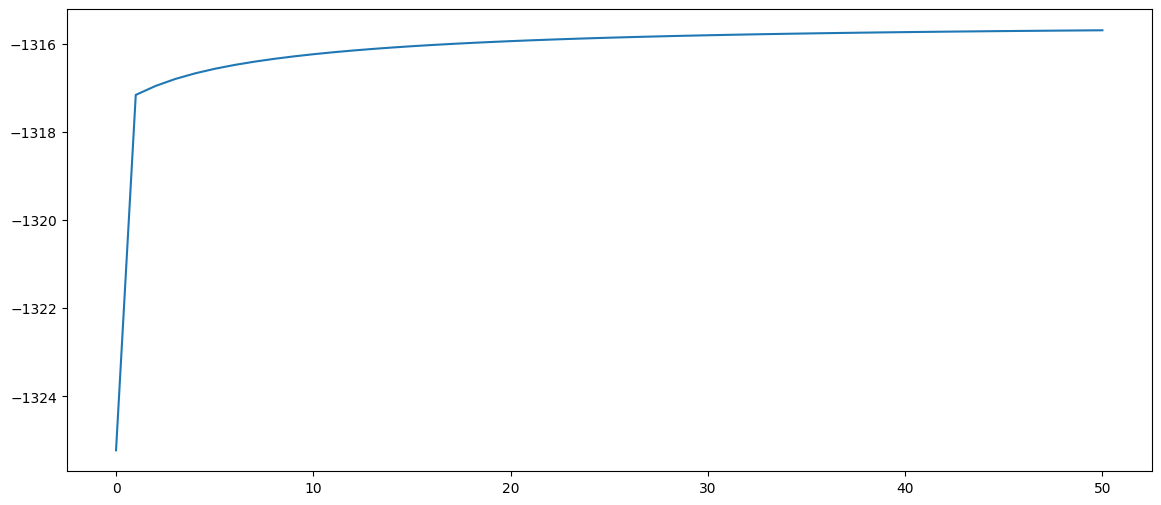

In [9]:
"""
Visualising the convergence of the negative log-likelihood
"""

plt.figure(figsize=(14,6))
plt.plot(log_probs)

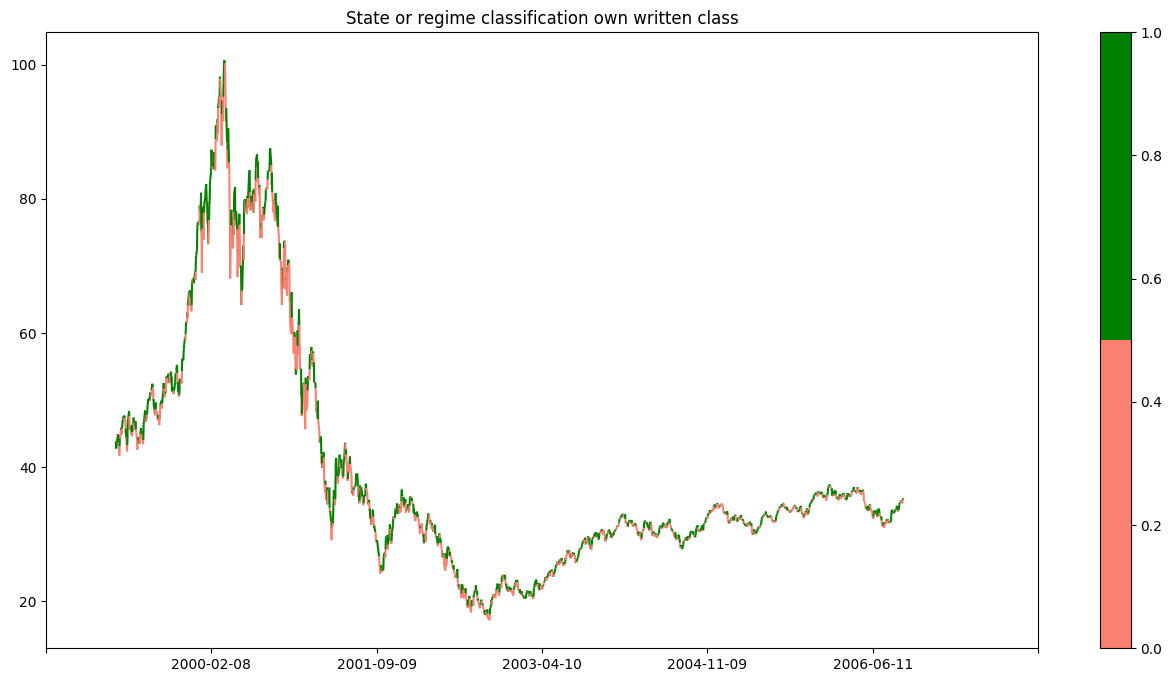

In [10]:
"""
Plotting the smoothed probabilities from the last iteration.
While the argmax function could be used to filter the most probable state
for every timestep, the last column from the gamma matrix is filtered here.
"""


x = qqq_split.index.to_numpy()
#np.datetime_as_string(x)
y = qqq_split.close
#z = state_probas[-1][:,1].copy()
z = np.where(state_probas[-1][:,1].copy() >= 0.6, 1, 0)


points = np.array([[x], [y]]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis = 1)
#segments[:,0,0].astype("datetime64[ns]")

#x_pos = segments[:,0,0].copy()
#x_labels = x_pos.astype("datetime64[ns]")

cmap = ListedColormap(["salmon", "green"])

fig, ax = plt.subplots(figsize=(16,8))
norm = plt.Normalize(z.min(), z.max())
lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(z)
ax.add_collection(lc)

ax.autoscale()
fig.colorbar(lc)
x_posis = ax.get_xticks()
x_posis.astype("datetime64[ns]")
plt.xticks(x_posis, ["", "2000-02-08", "2001-09-09", "2003-04-10", "2004-11-09", "2006-06-11", ""])
ax.set_title("State or regime classification own written class")
plt.sci(lc)
plt.show()


In [ ]:
###################################################################

In [ ]:
# Comparison of the own written class with the class from hmmlearn
# Only cetegorical is used here.

In [11]:
# Benchmarking against the CategoricalHMM-class from hmmlearn
# The "decoding" is used with "map" which are the smoothed probabilities or
# the forward-backward probabilities (gammas).
# For hmmlearn only numerical values are valid

observation_ints = observations[0].copy()
observation_ints = np.where(observation_ints == "up", 1, 0).reshape(-1, 1)

hmm_cat_qqq = hmm.CategoricalHMM(n_components=2, algorithm="map", init_params="", n_iter=10, implementation="scaling")
hmm_cat_qqq.startprob_ = np.array([0.8, 0.2])

hmm_cat_qqq.transmat_ = np.array([[0.6, 0.4],
                                  [0.3, 0.7]])

hmm_cat_qqq.emissionprob_ = np.array([[0.7, 0.3],
                                      [0.4, 0.6]])

hmm_cat_qqq_fit = hmm_cat_qqq.fit(X=observation_ints)

In [12]:
"""
Comparing the negative log-likelihoods.
"""

model_score_hmm_learn = hmm_cat_qqq_fit.score(X=observation_ints)

print(f"The negative log-likelihood from the own written class is: {log_probs[-1]}")
print(f"The negative log-likelihood from the hmmlearn package is: {model_score_hmm_learn}")

The negative log-likelihood from the own written class is: -1315.6970262095192
The negative log-likelihood from the hmmlearn package is: -1315.753264634938


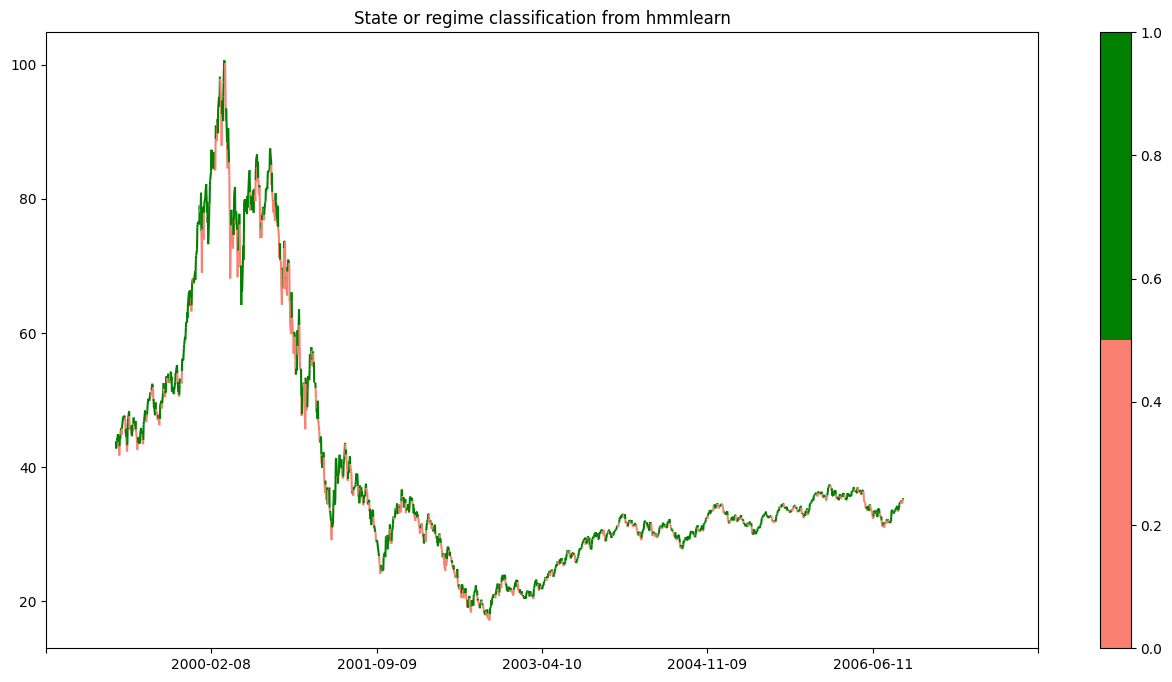

In [13]:
# Plot of the hmmlearn model

x = qqq_split.index.to_numpy()

y = qqq_split.close

z = hmm_cat_qqq_fit.predict(observation_ints)


points = np.array([[x], [y]]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis = 1)

cmap = ListedColormap(["salmon", "green"])
fig, ax = plt.subplots(figsize=(16,8))
#norm = plt.Normalize(z.min(), z.max())
#lc = LineCollection(segments, cmap=cmap, norm=norm)
lc = LineCollection(segments, cmap=cmap)
lc.set_array(z)
ax.add_collection(lc)

ax.autoscale()
x_posis = ax.get_xticks()
x_posis.astype("datetime64[ns]")
plt.xticks(x_posis, ["", "2000-02-08", "2001-09-09", "2003-04-10", "2004-11-09", "2006-06-11", ""])
fig.colorbar(lc, orientation="vertical")
ax.set_title("State or regime classification from hmmlearn")
plt.sci(lc)
plt.show()


Text(0.5, 1.0, 'Transition probabilities hmmlearn')

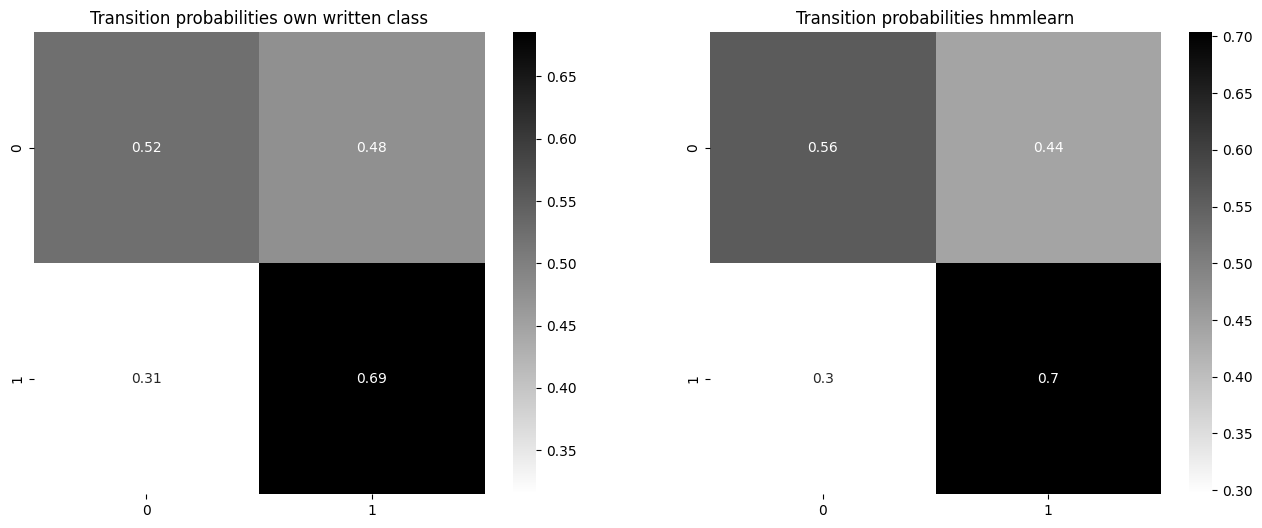

In [14]:
"""
Comparison with the transition matrix from the self written class.
"""
label_own = [x for x in transitions[-1]]

label_hmm = [x for x in hmm_cat_qqq_fit.transmat_]

fig, axs = plt.subplots(1,2, figsize=(16,6))

sns.heatmap(transitions[-1], annot=label_own, cmap="binary", ax=axs[0])
sns.heatmap(hmm_cat_qqq_fit.transmat_, annot=label_hmm, cmap="binary", ax=axs[1])
axs[0].set_title("Transition probabilities own written class")
axs[1].set_title("Transition probabilities hmmlearn")

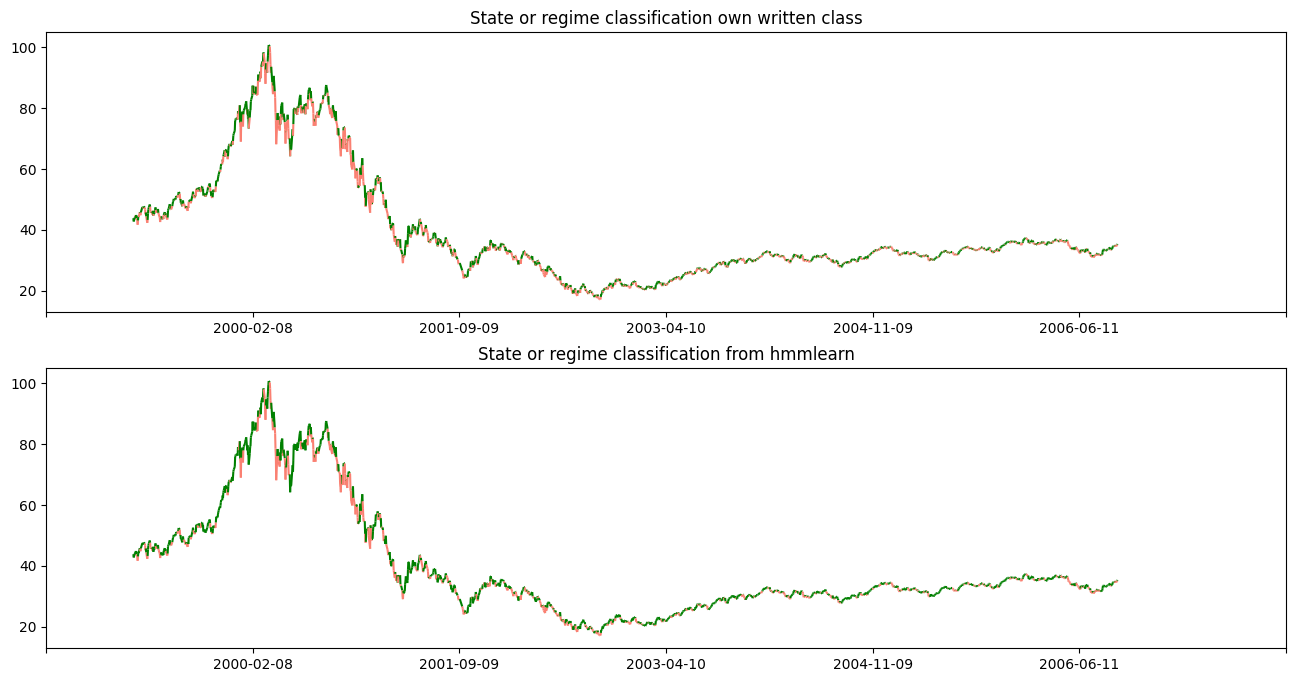

In [24]:
"""
Both price charts as subplots
"""

# Variables from the own written class for the subplots
x = qqq_split.index.to_numpy()
y = qqq_split.close
z = np.where(state_probas[-1][:,1].copy() >= 0.6, 1, 0)


# Variables from the hmmlearn package
# x and y are the same.
# Only the states are different (or not)
z_hmm_learn = hmm_cat_qqq_fit.predict(observation_ints)


points = np.array([[x], [y]]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis = 1)


# Plotting logic is defined here
# The color map is for both the same
cmap = ListedColormap(["salmon", "green"])

fig, ax = plt.subplots(2, figsize=(16,8))

lc = LineCollection(segments, cmap=cmap)
lc_learn = LineCollection(segments, cmap=cmap)
lc.set_array(z)
lc_learn.set_array(z_hmm_learn)
ax[0].add_collection(lc)
ax[1].add_collection(lc_learn)

ax[0].autoscale()
ax[1].autoscale()
#fig.colorbar(lc)
x_posis = ax[0].get_xticks()
x_posis.astype("datetime64[ns]")
ax[0].set_xticks(x_posis, ["", "2000-02-08", "2001-09-09", "2003-04-10", "2004-11-09", "2006-06-11", ""])
ax[1].set_xticks(x_posis, ["", "2000-02-08", "2001-09-09", "2003-04-10", "2004-11-09", "2006-06-11", ""])

ax[0].set_title("State or regime classification own written class")
ax[1].set_title("State or regime classification from hmmlearn")

plt.show()
